# Exercise

Training an MLP classifier on the mnist dataset using optuna tracked using MLflow

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import mlflow
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import v2


# MLflow config
mlflow.set_tracking_uri('sqlite:///mlflow.db')
mlflow.set_experiment('mnistDemo')

mlflow.config.enable_system_metrics_logging()
mlflow.config.set_system_metrics_sampling_interval(1)

# PyTorch config
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if torch.cuda.is_available():
    print(f'CUDA version: {torch.version.cuda}')

CUDA version: 13.0


In [3]:
def to_numpy(t: torch.Tensor) -> NDArray:
    '''Converts a tensor to a numpy array on the CPU'''
    return t.cpu().numpy()

## Data import and organization

In [7]:
transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize((0.1307,), (0.3081,))
])

train_dataset  = datasets.MNIST('data', train=True, transform=transform)
test_dataset  = datasets.MNIST('data', train=False, transform=transform)
MNIST_classes = datasets.MNIST('data').classes

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)
test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    num_workers=2,
    pin_memory=True
)

### Data exploration

In [8]:
batch, labels = next(iter(test_loader))

print(MNIST_classes)
print()

print(f'{len(train_loader) = }')
print(f'{len(test_loader) = }')
print(f'{batch.shape = }')
print(f'{labels.shape = }')

['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']

len(train_loader) = 938
len(test_loader) = 157
batch.shape = torch.Size([64, 1, 28, 28])
labels.shape = torch.Size([64])


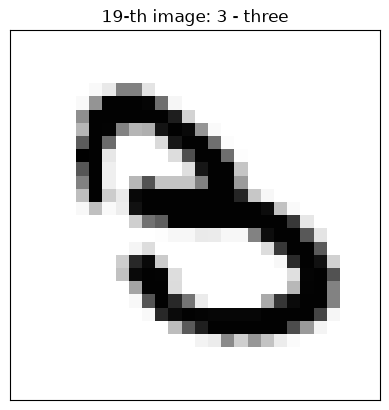

In [10]:
n = 18
im = to_numpy(batch[n, 0, :, :])
MNIST_class = MNIST_classes[labels[n]]

fig, ax = plt.subplots()
ax.imshow(im, cmap='Greys')

ax.set_xticks([])
ax.set_yticks([])
ax.set_title(f'{n+1}-th image: {MNIST_class}')

plt.show()

## Model and hyperparameter tuning setup

In [11]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.perceptron = nn.Sequential(
            nn.Linear(28 * 28, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.perceptron(x)
        return logits

model: MLP = MLP().to(device)